# SLORTA 
* [Dashboard](https://metabase.dds.dot.ca.gov/dashboard/361-agency-split-reconciliation)
* Figuring out why the numbers change based on download
* If this is happening for other questions or just Agency Split - Settled Amount?

In [ ]:
import google.auth
import pandas as pd
from calitp_data_analysis.sql import to_snakecase

In [ ]:
from calitp_data_analysis import get_fs
fs = get_fs()

In [ ]:
import google.auth
import pandas_gbq

credentials, project = google.auth.default()
from functools import cache

from calitp_data_analysis.gcs_pandas import GCSPandas
from calitp_data_analysis.gcs_geopandas import GCSGeoPandas

In [ ]:


@cache
def gcs_geopandas():
    return GCSGeoPandas()

In [ ]:
@cache
def gcs_pandas():
    return GCSPandas()

In [ ]:
pd.options.display.max_columns = 100
pd.options.display.float_format = "{:.2f}".format 
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

In [ ]:
slo_data_df = to_snakecase(pd.read_excel("gs://calitp-analytics-data/data-analyses/payments/slorta/query_result_2026-06-30T12_11_01.25013455-07_00.xlsx", sheet_name = "Query result"))

In [ ]:
slo_data_df.settlement_type.unique()

In [ ]:
slo_data_df.head()

In [ ]:
slo_device_crosswalk_df = to_snakecase(pd.read_csv("gs://calitp-analytics-data/data-analyses/payments/slo_terminalid_2026.csv"))

In [ ]:
slo_device_crosswalk_df.head(3)

In [ ]:
merge_test = pd.merge(slo_device_crosswalk_df, slo_data_df, left_on = "deviceidentifier", right_on = "device_id", how = "outer", indicator = True)

In [ ]:
merge_test._merge.value_counts()

In [ ]:
len(slo_data_df)

In [ ]:
m1 = pd.merge(slo_data_df, slo_device_crosswalk_df,  left_on = "device_id",right_on = "deviceidentifier", how = "left")

In [ ]:
m1['month'] = pd.to_datetime(m1['elavon_settlement_date']).dt.month

In [ ]:
m1.head()

In [ ]:
m1.groupby(["month","agency"]).agg({"elavon_amount":"sum"})

In [ ]:
m1.groupby(["month"]).agg({"elavon_amount":"sum"})

## Charge Amount
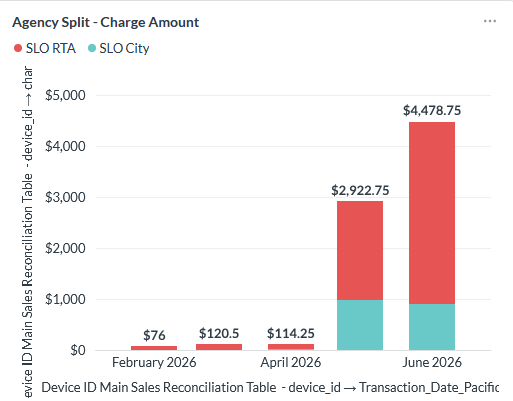

In [ ]:
slo_main_sales_df = to_snakecase(pd.read_excel("gs://calitp-analytics-data/data-analyses/payments/slorta/device_id_main_sales_recon.xlsx", sheet_name = "Query result"))

In [ ]:
slo_main_sales_df.sample()

In [ ]:
slo_main_sales_df = pd.merge(slo_main_sales_df, slo_device_crosswalk_df,  left_on = "device_id",right_on = "deviceidentifier", how = "left")

In [ ]:
slo_main_sales_df['month'] = pd.to_datetime(slo_main_sales_df['transaction_date_pacific']).dt.month

In [ ]:
slo_main_sales_df.groupby(["month","agency"]).agg({"nominal_amt_sum":"sum", "charge_amt_sum":"sum"})